## Exploratory Data Analysis

After completing data cleaning and recoding, exploratory data analysis was conducted to understand the basic characteristics of the cleaned dataset.

The purpose of this step is to examine the distribution of BMI percentile, check missing values, and compare BMI percentile across different levels of physical activity.

The EDA includes:

1. Descriptive statistics of the cleaned dataset
2. Missing value checking
3. Distribution of BMI percentile
4. BMI percentile comparison by physical activity days
5. Number of students by physical activity days

All EDA results are saved in the `output` folder. Figures are saved in `output/figures`, and tables are saved in `output/tables`.

This step helps provide an initial understanding of the data before performing regression analysis.

First five rows:
   PhysicalActivityDays  BMIPercentile     Sex       Grade
0                   1.0      66.531824    Male  10th grade
1                   0.0      98.174319  Female   9th grade
2                   0.0      33.075531  Female  11th grade
3                   6.0      45.688334  Female  11th grade
4                   5.0      62.390331  Female  11th grade

Descriptive Statistics:
       PhysicalActivityDays  BMIPercentile
count          12874.000000   1.287400e+04
mean               3.070840   6.485797e+01
std                2.563986   2.749125e+01
min                0.000000   3.720000e-09
25%                0.000000   4.523146e+01
50%                3.000000   7.020072e+01
75%                5.000000   8.945972e+01
max                7.000000   9.993921e+01

Missing Values:
PhysicalActivityDays    0
BMIPercentile           0
Sex                     0
Grade                   0
dtype: int64


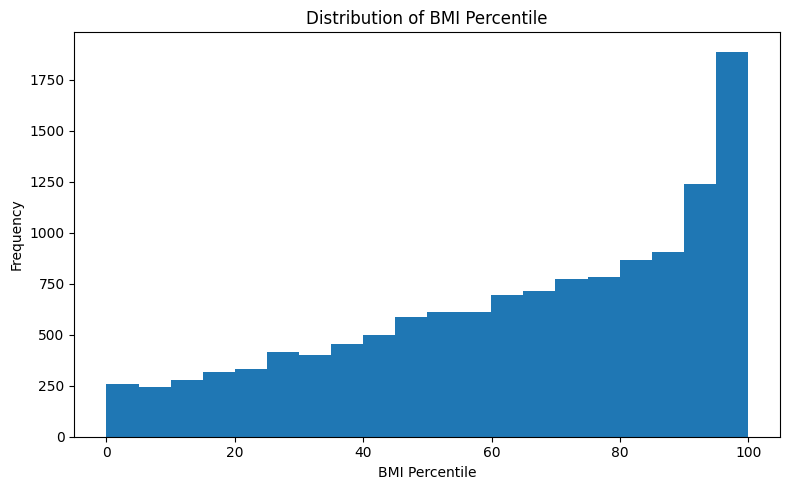

<Figure size 800x500 with 0 Axes>

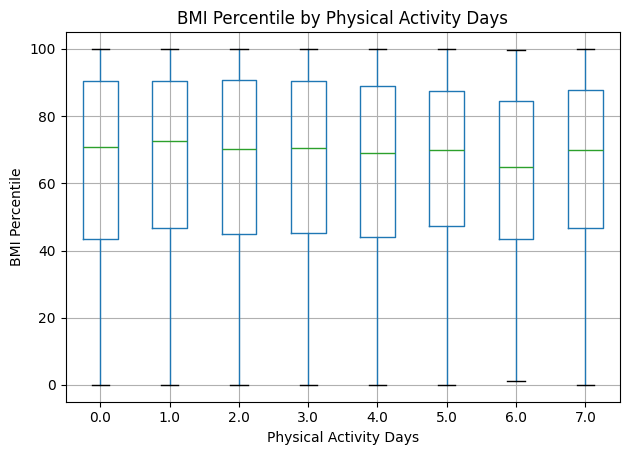

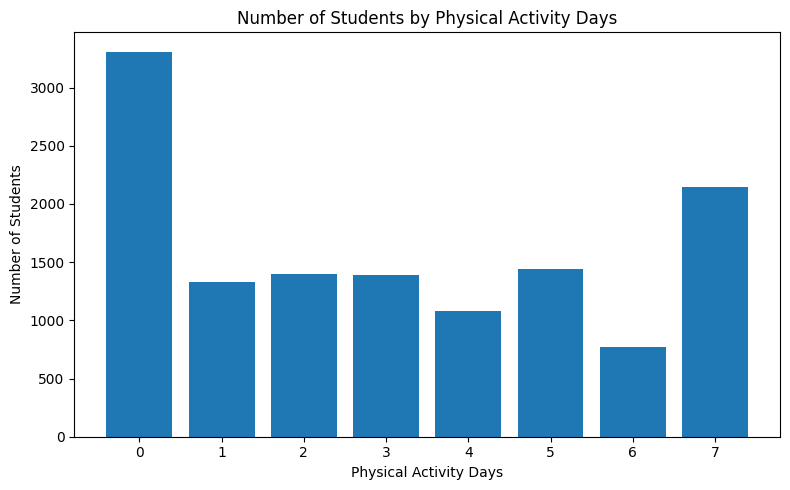


EDA completed.
Figures saved to:
C:\Users\curry\OneDrive\桌面\統計實習\2026-Spring-Stat-2-Final-Project\output\figures

Tables saved to:
C:\Users\curry\OneDrive\桌面\統計實習\2026-Spring-Stat-2-Final-Project\output\tables


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 讀取清理後資料
processed_path = r"C:\Users\curry\OneDrive\桌面\統計實習\2026-Spring-Stat-2-Final-Project\data\data processed\cleaned_yrbs_physical_activity_bmi.csv"

# output 主資料夾
output_dir = r"C:\Users\curry\OneDrive\桌面\統計實習\2026-Spring-Stat-2-Final-Project\output"

# output 裡面的分類資料夾
figures_dir = os.path.join(output_dir, "figures")
tables_dir = os.path.join(output_dir, "tables")

# 自動建立資料夾
os.makedirs(figures_dir, exist_ok=True)
os.makedirs(tables_dir, exist_ok=True)

# 讀取資料
data = pd.read_csv(processed_path)

# 查看資料前五筆
print("First five rows:")
print(data.head())

# 描述統計
desc_stats = data.describe()
print("\nDescriptive Statistics:")
print(desc_stats)

# 輸出描述統計表到 output/tables
desc_stats.to_csv(
    os.path.join(tables_dir, "descriptive_statistics.csv"),
    encoding="utf-8-sig"
)

# 檢查缺失值
missing_values = data.isna().sum()
print("\nMissing Values:")
print(missing_values)

# 輸出缺失值表到 output/tables
missing_values.to_csv(
    os.path.join(tables_dir, "missing_values.csv"),
    encoding="utf-8-sig"
)

# 圖一：BMI Percentile 分布圖
plt.figure(figsize=(8, 5))
plt.hist(data["BMIPercentile"], bins=20)
plt.xlabel("BMI Percentile")
plt.ylabel("Frequency")
plt.title("Distribution of BMI Percentile")
plt.tight_layout()
plt.savefig(
    os.path.join(figures_dir, "bmi_percentile_distribution.png"),
    dpi=300
)
plt.show()

# 圖二：不同運動天數的 BMI Percentile 箱型圖
plt.figure(figsize=(8, 5))
data.boxplot(column="BMIPercentile", by="PhysicalActivityDays")
plt.xlabel("Physical Activity Days")
plt.ylabel("BMI Percentile")
plt.title("BMI Percentile by Physical Activity Days")
plt.suptitle("")
plt.tight_layout()
plt.savefig(
    os.path.join(figures_dir, "bmi_by_physical_activity_days.png"),
    dpi=300
)
plt.show()

# 圖三：不同運動天數的人數分布
activity_counts = data["PhysicalActivityDays"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(activity_counts.index, activity_counts.values)
plt.xlabel("Physical Activity Days")
plt.ylabel("Number of Students")
plt.title("Number of Students by Physical Activity Days")
plt.tight_layout()
plt.savefig(
    os.path.join(figures_dir, "students_by_physical_activity_days.png"),
    dpi=300
)
plt.show()

print("\nEDA completed.")
print("Figures saved to:")
print(figures_dir)

print("\nTables saved to:")
print(tables_dir)